<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/LangGraph(Nodes_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install -q langgraph

In [6]:
import operator

from IPython.display import Image
from langchain_core.runnables import RunnablePassthrough
from langgraph.types import Runnable
from langgraph.graph import END, START, StateGraph
from pathlib import Path
from typing import Annotated, TypedDict

def display_graph(runnable: Runnable, output_png: Path) -> None:
    graph = runnable.get_graph()

    with output_png.open(mode = "wb") as file:
        file.write(graph.draw_mermaid_png())

    display(Image(output_png, format="png"))

In [7]:
class TextProcessingState(TypedDict):
    raw_text: str
    clean_text: str
    word_count: int
    tokens: list[str]
    log: Annotated[list[str], operator.add] # в log пазим натрупването на изпълнението на различните нодове, използваме Reducer, който долепя резултатите.

In [9]:
def normalize(state: TextProcessingState):
    cleaned = state["raw_text"].lower().strip()
    return { "clean_text":cleaned, "log": [f"normalized ({len(cleaned)} chars)"] }

def tokenize(state: TextProcessingState):
    tokens = [t for t in state["clean_text"].split() if t.isalpha()] # взима clean_text -> splitva по whitespaces и запазва само тези които съдържат букви
    return {"tokens": tokens, "log": [f"tokenized ({len(tokens)} tokens)"]}

def count_words(state: TextProcessingState): # count_words за да може да свърши работата си предварително се изпюлнява tokenize() и резултата се запазва в tokens полето
    return { "word_count": len(state["tokens"]), "log": [f"counted: {len(state['tokens'])} words."] }

def report(state: TextProcessingState) -> dict:
    print("===== REPORT =====")
    print(f"Original    : {state['raw_text']!r}")
    print(f"Normalized  : {state['clean_text']!r}")
    print(f"Word count  : {state['word_count']}")

    print("Log:")
    for line in state["log"]:
        print("- ", line)

    return {"log": ["reported"]}

In [10]:
graph_builder = StateGraph(TextProcessingState)
graph_builder.add_node("normalize", normalize)
graph_builder.add_node("tokenize", tokenize)
graph_builder.add_node("count", count_words)
graph_builder.add_node("report", report)

graph_builder.add_edge(START, "normalize")
graph_builder.add_edge("normalize", "tokenize")
graph_builder.add_edge("tokenize", "count")
graph_builder.add_edge("count", "report")
graph_builder.add_edge("report", END)

graph = graph_builder.compile()

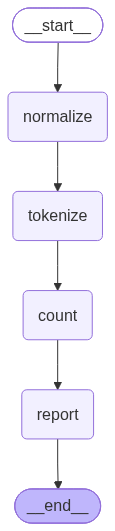

In [11]:
display_graph(graph, Path("/content/graph.png"))

In [15]:
input = { "raw_text": "Hello, world! Today we are talking about LangGraph and how to build multi-agent systems. 43324" }

In [16]:
final_state = graph.invoke(input)

===== REPORT =====
Original    : 'Hello, world! Today we are talking about LangGraph and how to build multi-agent systems. 43324'
Normalized  : 'hello, world! today we are talking about langgraph and how to build multi-agent systems. 43324'
Word count  : 10
Log:
-  normalized (94 chars)
-  tokenized (10 tokens)
-  counted: 10 words.


In [17]:
final_state

{'raw_text': 'Hello, world! Today we are talking about LangGraph and how to build multi-agent systems. 43324',
 'clean_text': 'hello, world! today we are talking about langgraph and how to build multi-agent systems. 43324',
 'word_count': 10,
 'tokens': ['today',
  'we',
  'are',
  'talking',
  'about',
  'langgraph',
  'and',
  'how',
  'to',
  'build'],
 'log': ['normalized (94 chars)',
  'tokenized (10 tokens)',
  'counted: 10 words.',
  'reported']}